In [1]:
from qiskit.converters import dag_to_circuit
from qiskit.dagcircuit import DAGCircuit
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_dag
from qiskit.dagcircuit import DAGDependency
from qiskit.visualization import circuit_drawer
from qiskit.visualization import dag_drawer



def flatten_dag_to_linear(dag):
    """
    Convert a DAGCircuit into a single-path DAG
    by serializing operations in topological order.
    """

    # Create a new empty DAG
    linear_dag = DAGCircuit()
    linear_dag.add_qreg(dag.qregs["q"])
    
    # Copy classical registers if present
    for creg in dag.cregs.values():
        linear_dag.add_creg(creg)

    # Iterate in topological order
    for node in dag.topological_op_nodes():
        linear_dag.apply_operation_back(
            node.op,
            qargs=node.qargs,
            cargs=node.cargs
        )

    return linear_dag

def load_qasm_to_dag(qasm_path: str):
    qc = QuantumCircuit.from_qasm_file(qasm_path)
    dag = circuit_to_dag(qc)
    return dag

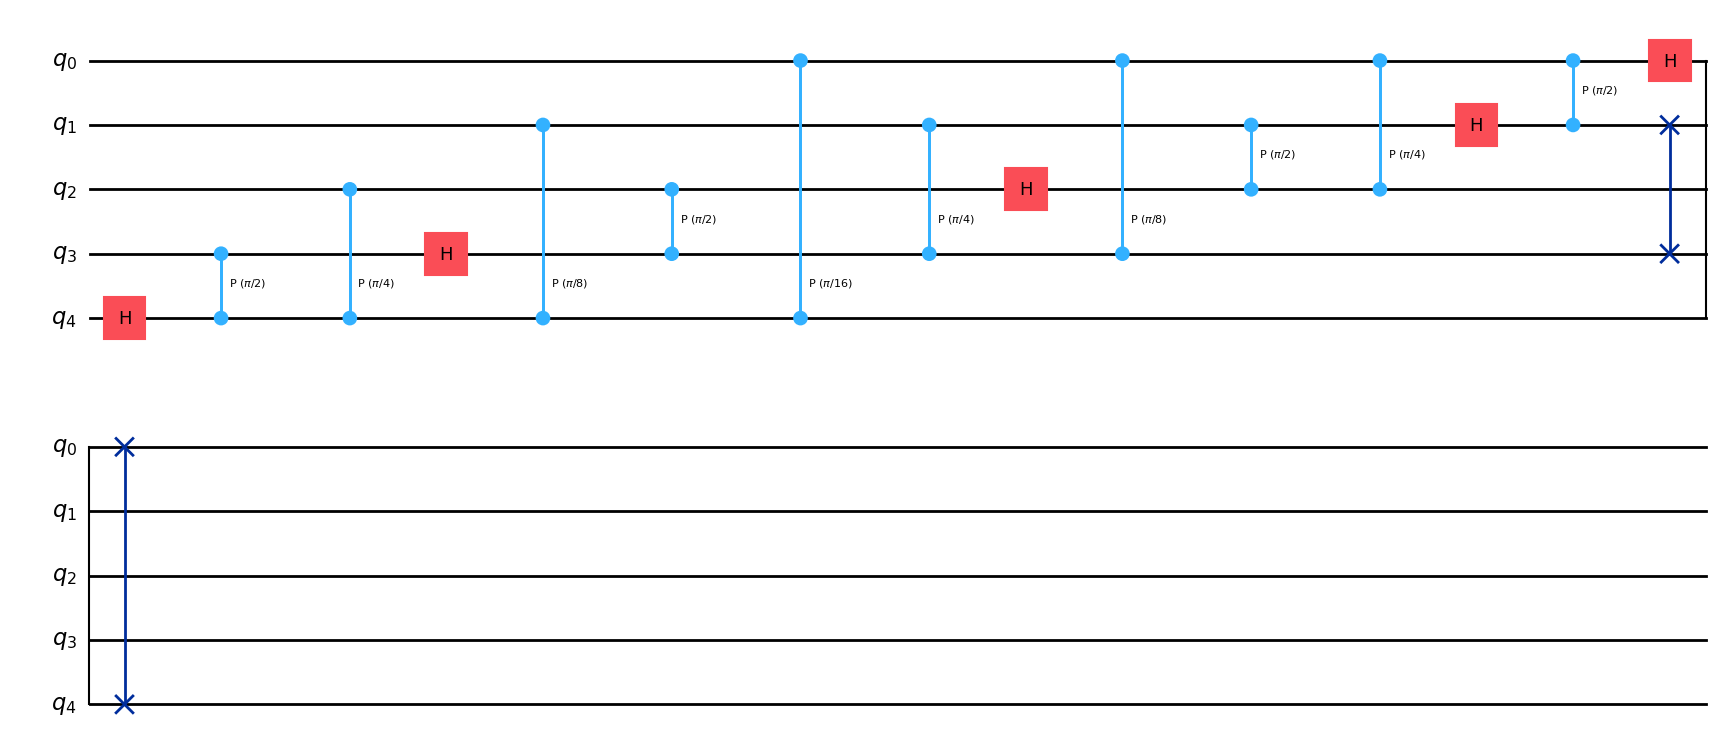

In [2]:
qc = QuantumCircuit.from_qasm_file("inputs/qasm_files/qft_5.qasm")
qc.draw("mpl")


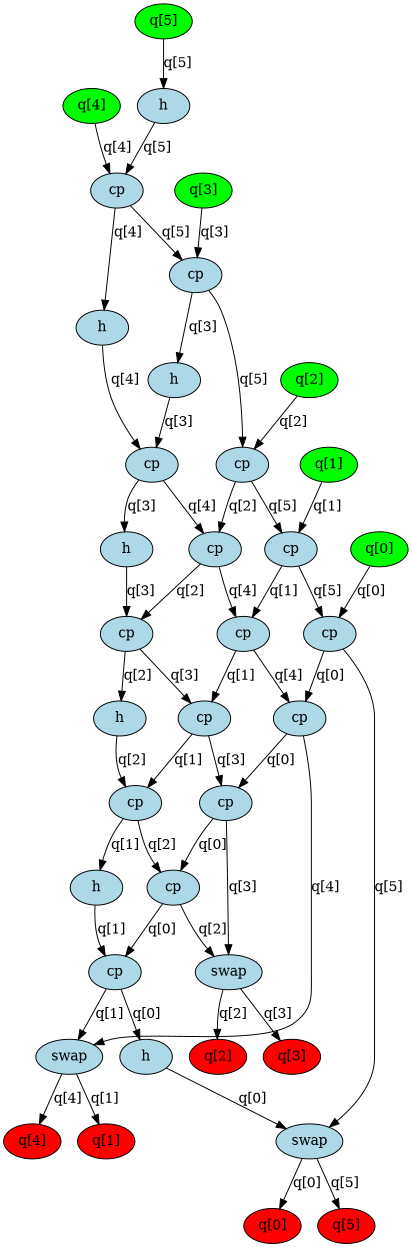

In [3]:
qc = QuantumCircuit.from_qasm_file("inputs/qasm_files/qft_6.qasm")
dag = circuit_to_dag(qc)

dag_drawer(dag)

In [10]:
qc = QuantumCircuit.from_qasm_file("inputs/qasm_files/qft_n63_transpiled.qasm")
dag = circuit_to_dag(qc)
list1 = dag.topological_op_nodes()

In [5]:
for node in list1:
    print(node.name, node.qargs, node.cargs)

h (<Qubit register=(6, "q"), index=5>,) ()
cp (<Qubit register=(6, "q"), index=5>, <Qubit register=(6, "q"), index=4>) ()
h (<Qubit register=(6, "q"), index=4>,) ()
cp (<Qubit register=(6, "q"), index=5>, <Qubit register=(6, "q"), index=3>) ()
h (<Qubit register=(6, "q"), index=3>,) ()
cp (<Qubit register=(6, "q"), index=4>, <Qubit register=(6, "q"), index=3>) ()
h (<Qubit register=(6, "q"), index=3>,) ()
cp (<Qubit register=(6, "q"), index=5>, <Qubit register=(6, "q"), index=2>) ()
cp (<Qubit register=(6, "q"), index=4>, <Qubit register=(6, "q"), index=2>) ()
cp (<Qubit register=(6, "q"), index=3>, <Qubit register=(6, "q"), index=2>) ()
h (<Qubit register=(6, "q"), index=2>,) ()
cp (<Qubit register=(6, "q"), index=5>, <Qubit register=(6, "q"), index=1>) ()
cp (<Qubit register=(6, "q"), index=4>, <Qubit register=(6, "q"), index=1>) ()
cp (<Qubit register=(6, "q"), index=3>, <Qubit register=(6, "q"), index=1>) ()
cp (<Qubit register=(6, "q"), index=2>, <Qubit register=(6, "q"), index=1>

In [13]:
layers = list(dag.layers())
layers[1]["graph"].op_nodes()

[DAGOpNode(op=Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]), qargs=(<Qubit register=(63, "q"), index=0>,), cargs=())]

In [51]:
#TODO: split the dag into layers. The layer hold gates that can be done simultaneously.
#TODO: Bin the gates that are done in each layer and place them in such a way that they create a better placement
qc = QuantumCircuit.from_qasm_file("inputs/qasm_files/qft_6.qasm")
dag = circuit_to_dag(qc)
layers = list(dag.layers())

TypeError: 'tuple_iterator' object is not callable

In [14]:
layers[2]["graph"].op_nodes()

[DAGOpNode(op=Instruction(name='rz', num_qubits=1, num_clbits=0, params=[1.5707963267948966]), qargs=(<Qubit register=(63, "q"), index=0>,), cargs=())]

In [62]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.dagcircuit import DAGCircuit

qc = QuantumCircuit.from_qasm_file("inputs/qasm_files/qft_5.qasm")
dag = circuit_to_dag(qc)

# Create a new empty DAG with same registers
new_dag = DAGCircuit()
for qreg in qc.qregs:
    new_dag.add_qreg(qreg)
for creg in qc.cregs:
    new_dag.add_creg(creg)

# Copy only multi-qubit ops
for node in dag.topological_op_nodes():
    if len(node.qargs) > 1:  # keep only multi-qubit gates
        new_dag.apply_operation_back(node.op, node.qargs, node.cargs)

# Convert back to circuit if needed
filtered_qc = dag_to_circuit(new_dag)

In [63]:
dag = circuit_to_dag(qc)
op_nodes = list(dag.topological_op_nodes())

In [64]:
for pos,node in enumerate(op_nodes):
    print(pos, node.name, node.qargs)

0 h (<Qubit register=(5, "q"), index=4>,)
1 cp (<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=3>)
2 h (<Qubit register=(5, "q"), index=3>,)
3 cp (<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=2>)
4 cp (<Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=2>)
5 h (<Qubit register=(5, "q"), index=2>,)
6 cp (<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=1>)
7 cp (<Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=1>)
8 cp (<Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=1>)
9 h (<Qubit register=(5, "q"), index=1>,)
10 cp (<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=0>)
11 cp (<Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=0>)
12 cp (<Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=0>)
13 cp (<Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=0>)
14 h (<Qubit register=(5, "q"), index=0>,)
15 sw

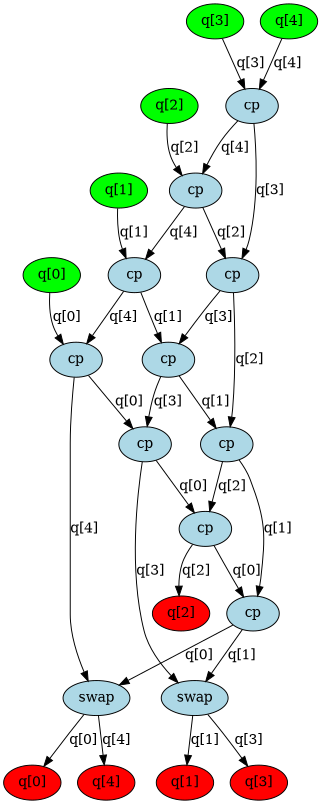

In [65]:
dag_drawer(new_dag)

In [14]:
from naive_n_dag.dag_helper import load_qasm_to_two_qubit_dag_with_single_qubit_context
test = load_qasm_to_two_qubit_dag_with_single_qubit_context("inputs/qasm_files/qft_6.qasm")

In [19]:
test[0]

In [21]:
layers = list(test[0].layers())

In [23]:
len(layers)

9

In [99]:
for layer_nodes in layers:
    for node in layer_nodes["graph"].op_nodes():
        print(node.qargs[1])

<Qubit register=(6, "q"), index=4>
<Qubit register=(6, "q"), index=3>
<Qubit register=(6, "q"), index=3>
<Qubit register=(6, "q"), index=2>
<Qubit register=(6, "q"), index=2>
<Qubit register=(6, "q"), index=1>
<Qubit register=(6, "q"), index=2>
<Qubit register=(6, "q"), index=1>
<Qubit register=(6, "q"), index=0>
<Qubit register=(6, "q"), index=1>
<Qubit register=(6, "q"), index=0>
<Qubit register=(6, "q"), index=1>
<Qubit register=(6, "q"), index=0>
<Qubit register=(6, "q"), index=0>
<Qubit register=(6, "q"), index=0>


In [77]:
type(test[0])

qiskit._accelerate.circuit.DAGCircuit

In [24]:
layers

[{'graph': <qiskit._accelerate.circuit.DAGCircuit at 0x8cfb290>,
  'partition': [(<Qubit register=(6, "q"), index=5>,
    <Qubit register=(6, "q"), index=4>)]},
 {'graph': <qiskit._accelerate.circuit.DAGCircuit at 0x8df1070>,
  'partition': [(<Qubit register=(6, "q"), index=5>,
    <Qubit register=(6, "q"), index=3>)]},
 {'graph': <qiskit._accelerate.circuit.DAGCircuit at 0x8df1c70>,
  'partition': [(<Qubit register=(6, "q"), index=4>,
    <Qubit register=(6, "q"), index=3>),
   (<Qubit register=(6, "q"), index=5>, <Qubit register=(6, "q"), index=2>)]},
 {'graph': <qiskit._accelerate.circuit.DAGCircuit at 0x8df2870>,
  'partition': [(<Qubit register=(6, "q"), index=4>,
    <Qubit register=(6, "q"), index=2>),
   (<Qubit register=(6, "q"), index=5>, <Qubit register=(6, "q"), index=1>)]},
 {'graph': <qiskit._accelerate.circuit.DAGCircuit at 0x8df3470>,
  'partition': [(<Qubit register=(6, "q"), index=3>,
    <Qubit register=(6, "q"), index=2>),
   (<Qubit register=(6, "q"), index=4>, <Qu

In [ ]:
layers = list(test[0].layers())
layers[3]["graph"].op_nodes()

[DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[0.7853981633974483]), qargs=(<Qubit register=(8, "q"), index=6>, <Qubit register=(8, "q"), index=4>), cargs=()),
 DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[0.19634954084936207]), qargs=(<Qubit register=(8, "q"), index=7>, <Qubit register=(8, "q"), index=3>), cargs=())]

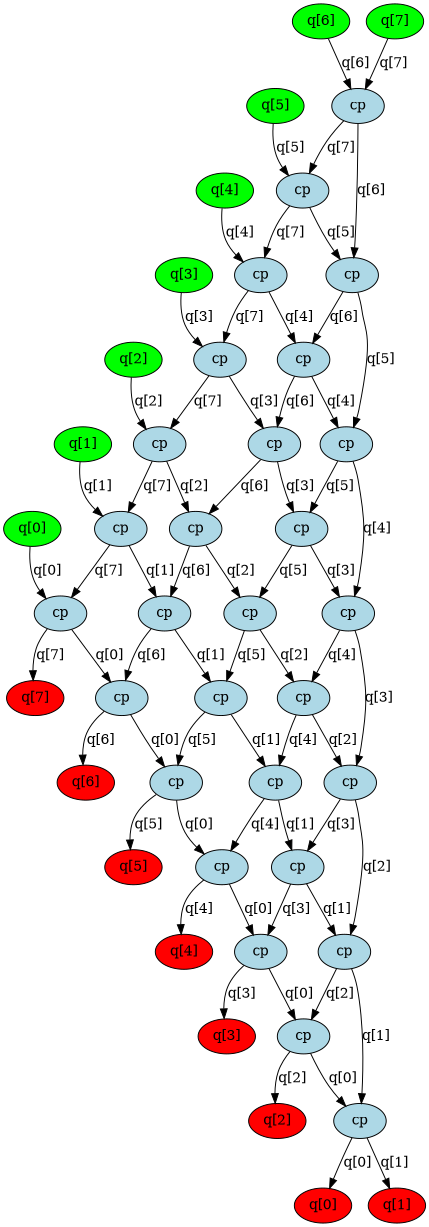

In [49]:
dag_drawer(test[0])

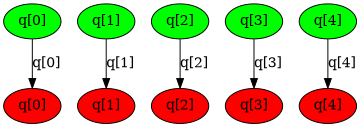

In [5]:
linear_dag = DAGCircuit()
linear_dag.add_qreg(dag.qregs["q"])

dag_drawer(linear_dag)

In [6]:
for d in dag.collect_2q_runs():
    print(d)

[DAGOpNode(op=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qargs=(<Qubit register=(5, "q"), index=4>,), cargs=()), DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[1.5707963267948966]), qargs=(<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=3>), cargs=()), DAGOpNode(op=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qargs=(<Qubit register=(5, "q"), index=3>,), cargs=())]
[DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[0.7853981633974483]), qargs=(<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=2>), cargs=())]
[DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[1.5707963267948966]), qargs=(<Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=2>), cargs=()), DAGOpNode(op=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qargs=(<Qubit register=(5, "q"), index=2>,), cargs=())]
[DAGOpNode(op=Instruction(name='cp', num_qubits=2

In [7]:
dag.node(16)
#TODO: turn circuit into dag, get rid of unnecessary gate operations, do add barrier before measurments, and preform operations in direction of dag.

DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[0.39269908169872414]), qargs=(<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=1>), cargs=())

In [8]:
from naive_dag.dag_helper import dag_with_gate_ops_only
dag1=dag_with_gate_ops_only(dag)

In [26]:
print("gate_name: ", dag1[1].op.name)
print("params: ", [q for q in dag1[1].op.params])

gate_name:  cp
params:  [1.5707963267948966]


In [38]:
dag1[1].qargs[1]

<Qubit register=(5, "q"), index=3>

In [40]:
for node in dag.topological_op_nodes():
    print(node.op.name, [q.index for q in node.qargs], node.op.params)


AttributeError: 'qiskit.circuit.Qubit' object has no attribute 'index'

In [114]:
node = dag1[1]  # example

gate_name = node.op.name
params = node.op.params
qubits = [q for q in node.qargs]

print(gate_name, params, qubits)


cp [1.5707963267948966] [<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=3>]


In [131]:
def op_node_signature(node: DAGOpNode) -> tuple[str, list[float], list[int]]:
    """
    Return (gate_name, params, qubit_indices) for a DAGOpNode.

    Qubit indices are extracted from node.qargs (e.g., q[3] -> 3).
    """
    gate_name = node.op.name
    params = [float(p) for p in getattr(node.op, "params", [])]
    qubit_indices: list[int] = []
    for q in node.qargs:
        rep = repr(q)
        if "index=" not in rep:
            raise ValueError(f"Unable to extract qubit index from {rep}")
        idx_str = rep.split("index=", 1)[1].split(">", 1)[0].strip()
        idx = int(idx_str)
        qubit_indices.append(int(idx))
    return gate_name, params, qubit_indices


In [138]:
dag1[6]

DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[0.39269908169872414]), qargs=(<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=1>), cargs=())

In [1]:
%load_ext autoreload
%autoreload 2
from naive_dag.grid import generate_grid
from naive_dag.grid import naive_fill
from naive_dag.grid import move_qubit
from naive_dag.dag_helper import load_qasm_to_gate_dag
from naive_dag.dynamics import gate_qubits
from naive_dag.dynamics import _start_
from naive_dag.dynamics import _shuttle_
from naive_dag.dynamics import best_path_for_gate


In [2]:
qc = load_qasm_to_gate_dag("inputs/qasm_files/qft_6.qasm")
grid = generate_grid([3,3],1)
qubits = naive_fill(grid,6,0,True)

In [5]:
qc[0].op

Instruction(name='h', num_qubits=1, num_clbits=0, params=[])

In [100]:
len(qc)

21

In [82]:
q1, q2 = gate_qubits(qc, 1, qubits)
print(q1.grid_position())
print(q2.grid_position())

(2, 2)
(0, 4)


In [83]:
moves=best_path_for_gate(qc,1,qubits,grid)
moves

[(2, 2), (1, 2), (1, 4)]

In [84]:
q1, q2 = gate_qubits(qc, 3, qubits)
print(q1.grid_position())
print(q2.grid_position())

(1, 4)
(0, 0)


In [85]:
moves=best_path_for_gate(qc,3,qubits,grid)
moves

[(1, 4), (1, 0), (1, 2), (0, 2)]

In [ ]:
gate_qubits(qc, 3, qubits)

In [90]:
from naive_dag.main import resolve_config_paths
from naive_dag.main import load_config
import pint
ureg = pint.UnitRegistry()
config = load_config("inputs/algorithms/qft_06.json")

In [96]:
import json
import pint

ureg = pint.UnitRegistry()

with open("inputs/algorithms/qft_06.json") as f:
    config = json.load(f)

def to_quantity(d):
    return d["value"] * ureg(d["units"])

config["transfer_SLM_AOD"] = to_quantity(config["transfer_SLM_AOD"])
config["max_acceleration"] = to_quantity(config["max_acceleration"])
config["max_velocity"] = to_quantity(config["max_velocity"])
config["rydberg_radius"] = to_quantity(config["rydberg_radius"])

In [97]:
config["transfer_SLM_AOD"] = config["transfer_SLM_AOD"].to("seconds")

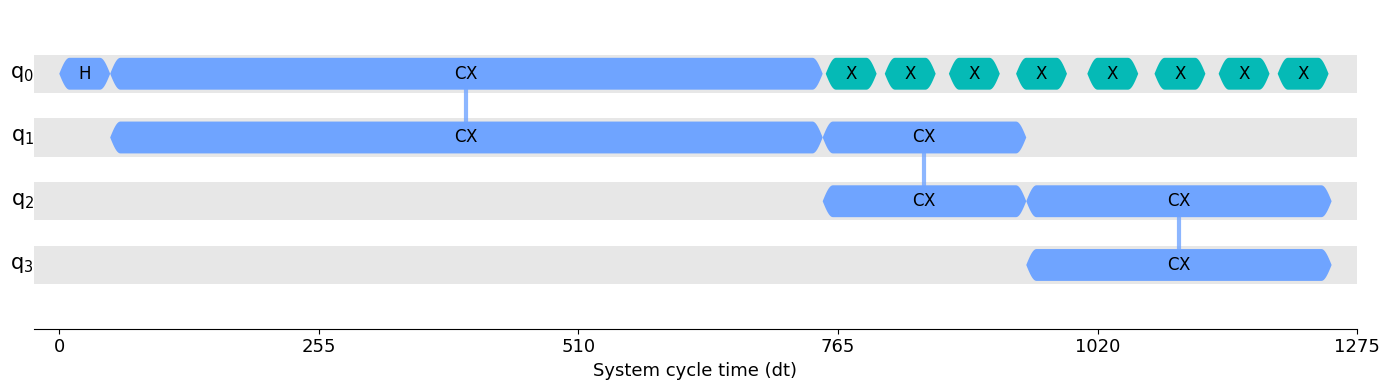

In [115]:
import numpy as np
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager, InstructionDurations, Target, CouplingMap
from qiskit.transpiler.passes import ALAPScheduleAnalysis, PadDynamicalDecoupling
from qiskit.visualization import timeline_drawer

circ = QuantumCircuit(4)
circ.h(0)
circ.cx(0, 1)
circ.cx(1, 2)
circ.cx(2, 3)
durations = InstructionDurations(
    [("h", 0, 50), ("cx", [0, 1], 700), ("reset", None, 10),
     ("cx", [1, 2], 200), ("cx", [2, 3], 300),
     ("x", None, 50), ("measure", None, 1000)],
    dt=1e-7
)
target = Target.from_configuration(
    ["h", "cx", "reset", "x", "measure"],
    num_qubits=4,
    coupling_map=CouplingMap.from_line(4, bidirectional=False),
    instruction_durations=durations,
    dt=1e-7,
)

# balanced X-X sequence on all qubits
dd_sequence = [XGate(), XGate()]
pm = PassManager([ALAPScheduleAnalysis(durations),
                  PadDynamicalDecoupling(durations, dd_sequence)])
circ_dd = pm.run(circ)
timeline_drawer(circ_dd, target=target)

# Uhrig sequence on qubit 0
n = 8
dd_sequence = [XGate()] * n
def uhrig_pulse_location(k):
    return np.sin(np.pi * (k + 1) / (2 * n + 2)) ** 2
spacing = []
for k in range(n):
    spacing.append(uhrig_pulse_location(k) - sum(spacing))
spacing.append(1 - sum(spacing))
pm = PassManager(
    [
        ALAPScheduleAnalysis(durations),
        PadDynamicalDecoupling(durations, dd_sequence, qubits=[0], spacing=spacing),
    ]
)
circ_dd = pm.run(circ)
timeline_drawer(circ_dd, target=target)

In [116]:
durations

In [6]:
from naive_n_dag.grid import generate_grid
from naive_n_dag.grid import naive_fill
from copy import deepcopy

grid = generate_grid([3,3],1)
qubits = naive_fill(grid,6,0,True)


In [7]:
grid

[[GridNode(x=0.0, y=0.0, row=0, col=0, qubit=Qubit(id=2, node=...)),
  GridNode(x=0.5, y=0.0, row=0, col=1, qubit=None),
  GridNode(x=1.0, y=0.0, row=0, col=2, qubit=None),
  GridNode(x=1.5, y=0.0, row=0, col=3, qubit=None),
  GridNode(x=2.0, y=0.0, row=0, col=4, qubit=Qubit(id=3, node=...))],
 [GridNode(x=0.0, y=0.5, row=1, col=0, qubit=None),
  GridNode(x=0.5, y=0.5, row=1, col=1, qubit=None),
  GridNode(x=1.0, y=0.5, row=1, col=2, qubit=None),
  GridNode(x=1.5, y=0.5, row=1, col=3, qubit=None),
  GridNode(x=2.0, y=0.5, row=1, col=4, qubit=None)],
 [GridNode(x=0.0, y=1.0, row=2, col=0, qubit=Qubit(id=5, node=...)),
  GridNode(x=0.5, y=1.0, row=2, col=1, qubit=None),
  GridNode(x=1.0, y=1.0, row=2, col=2, qubit=Qubit(id=4, node=...)),
  GridNode(x=1.5, y=1.0, row=2, col=3, qubit=None),
  GridNode(x=2.0, y=1.0, row=2, col=4, qubit=None)],
 [GridNode(x=0.0, y=1.5, row=3, col=0, qubit=None),
  GridNode(x=0.5, y=1.5, row=3, col=1, qubit=None),
  GridNode(x=1.0, y=1.5, row=3, col=2, qubit=

In [8]:
grid_copy = deepcopy(grid)
grid_copy

[[GridNode(x=0.0, y=0.0, row=0, col=0, qubit=Qubit(id=2, node=...)),
  GridNode(x=0.5, y=0.0, row=0, col=1, qubit=None),
  GridNode(x=1.0, y=0.0, row=0, col=2, qubit=None),
  GridNode(x=1.5, y=0.0, row=0, col=3, qubit=None),
  GridNode(x=2.0, y=0.0, row=0, col=4, qubit=Qubit(id=3, node=...))],
 [GridNode(x=0.0, y=0.5, row=1, col=0, qubit=None),
  GridNode(x=0.5, y=0.5, row=1, col=1, qubit=None),
  GridNode(x=1.0, y=0.5, row=1, col=2, qubit=None),
  GridNode(x=1.5, y=0.5, row=1, col=3, qubit=None),
  GridNode(x=2.0, y=0.5, row=1, col=4, qubit=None)],
 [GridNode(x=0.0, y=1.0, row=2, col=0, qubit=Qubit(id=5, node=...)),
  GridNode(x=0.5, y=1.0, row=2, col=1, qubit=None),
  GridNode(x=1.0, y=1.0, row=2, col=2, qubit=Qubit(id=4, node=...)),
  GridNode(x=1.5, y=1.0, row=2, col=3, qubit=None),
  GridNode(x=2.0, y=1.0, row=2, col=4, qubit=None)],
 [GridNode(x=0.0, y=1.5, row=3, col=0, qubit=None),
  GridNode(x=0.5, y=1.5, row=3, col=1, qubit=None),
  GridNode(x=1.0, y=1.5, row=3, col=2, qubit=

In [12]:
from collections import Counter
counts = Counter([(1,1),(1,2),(1,1)])

In [13]:
counts

Counter({(1, 1): 2, (1, 2): 1})

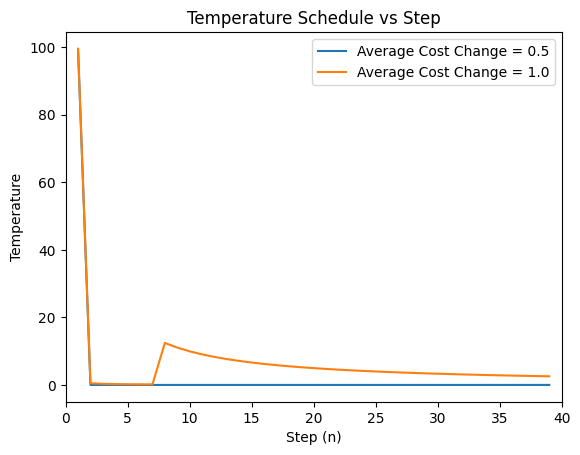

In [69]:
import math
import matplotlib.pyplot as plt

from math import log

def _temperature_for_step(
    n: int,
    *,
    average_uphill_cost: float,
    initial_accept_prob: float,
    average_cost_change: float,
    k: int,
    c: float,
) -> float:
    denom = log(initial_accept_prob)

    # ensure denom is not zero
    if abs(denom) < 1e-12:
        denom = -1e-12

    # make temperature positive
    t1 = -average_uphill_cost / denom

    if n <= 1:
        return t1
    if n <= k:
        return max((t1 * average_cost_change) / (n * c), 1e-12)
    return max((t1 * average_cost_change) / n, 1e-12)

# Example average uphill cost
avg_uphill_cost = 1.0

# Generate values
k = 7
n_values = list(range(1, 40))
temps = [_temperature_for_step(n, average_uphill_cost=avg_uphill_cost, initial_accept_prob=0.99, average_cost_change=-.5, k=k, c=100) for n in n_values]
temps2 = [_temperature_for_step(n, average_uphill_cost=avg_uphill_cost, initial_accept_prob=0.99, average_cost_change=1.0, k=k, c=100) for n in n_values]

# Plot
plt.figure()
plt.plot(n_values, temps, label="Average Cost Change = 0.5")
plt.plot(n_values, temps2, label="Average Cost Change = 1.0")
plt.xlabel("Step (n)")
plt.ylabel("Temperature")
plt.xlim(0, 40)
plt.title("Temperature Schedule vs Step")
plt.legend()
plt.show()

In [70]:
temps

[99.49916247342207,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12,
 1e-12]